Titanic Dataset

In [1]:
import pandas as pd
import os

# Create raw data folder if not exists
os.makedirs("../data/raw", exist_ok=True)

# Titanic dataset URL (Kaggle mirror)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Download dataset
df = pd.read_csv(url)

# Save into project folder
df.to_csv("../data/raw/titanic.csv", index=False)

print("Dataset downloaded successfully!")
print(df.shape)

df.head()

Dataset downloaded successfully!
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

Load Dataset

In [3]:
df = pd.read_csv("../data/raw/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check Dataset Shape

In [4]:
print("Rows and Columns:")
df.shape

Rows and Columns:


(891, 12)

Check Column Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Statistical Summary

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Check Missing Values

In [7]:
missing_values = df.isnull().sum()

missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Check Duplicate Rows

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


Unique Values

In [9]:
for column in df.columns:
    print("\n", column)
    print(df[column].nunique())


 PassengerId
891

 Survived
2

 Pclass
3

 Name
891

 Sex
2

 Age
88

 SibSp
7

 Parch
7

 Ticket
681

 Fare
248

 Cabin
147

 Embarked
3


Dataset Summary Report

In [10]:
print("="*50)
print("TITANIC DATASET UNDERSTANDING")
print("="*50)

print("Total Records:", df.shape[0])
print("Total Features:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

TITANIC DATASET UNDERSTANDING
Total Records: 891
Total Features: 12

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Records: 0


# 🧹 Data Cleaning

In this section, we will clean the Titanic dataset by handling missing values, removing unnecessary columns, and preparing the dataset for Exploratory Data Analysis.

In [11]:
# Checking missing values before cleaning

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Handle Missing Values

In [13]:
# Fill missing Age values with median

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Fill missing Embarked values

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Drop Cabin column

df = df.drop(
    "Cabin",
    axis=1
)

Remove Unnecessary Columns

In [14]:
# Drop unnecessary columns

df = df.drop(
    [
        "PassengerId",
        "Name",
        "Ticket"
    ],
    axis=1
)

Check Duplicate Records

In [15]:
# Check duplicate rows

df.duplicated().sum()

np.int64(116)

Verify Cleaning

In [16]:
# Check remaining missing values

print("Missing Values After Cleaning:")
print(df.isnull().sum())


print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing Values After Cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Dataset Shape After Cleaning:
(891, 8)


## Saving Cleaned Dataset

The cleaned dataset is saved into the processed folder for further EDA and analysis.

In [18]:
# Save cleaned dataset

import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/titanic_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


data load

In [20]:
# Load cleaned dataset for EDA

df_clean = pd.read_csv(
    "../data/processed/titanic_cleaned.csv"
)

df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# 📊 Exploratory Data Analysis (EDA)

In this section, we analyze the cleaned Titanic dataset to identify patterns, relationships, and factors that influenced passenger survival.

The analysis includes:

- Survival distribution
- Gender survival analysis
- Passenger class analysis
- Age distribution
- Fare analysis
- Family survival analysis
- Correlation analysis

## 1. Survival Distribution

This analysis shows the number of passengers who survived and those who did not survive the Titanic disaster.

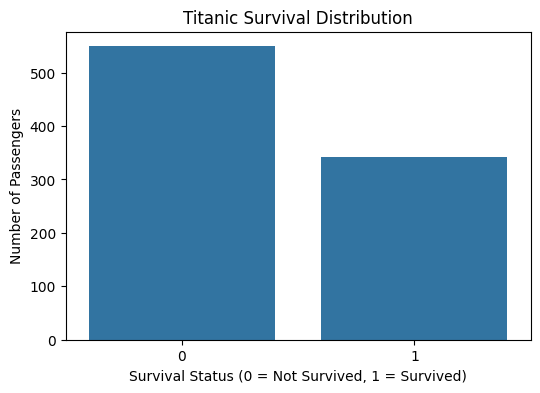

Chart saved successfully!


In [25]:
from pathlib import Path

# Create results folder if it doesn't exist
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="Survived"
)

plt.title("Titanic Survival Distribution")

plt.xlabel("Survival Status (0 = Not Survived, 1 = Survived)")

plt.ylabel("Number of Passengers")

# Save the chart
plt.savefig(
    results_dir / "survival_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

print("Chart saved successfully!")

the survival percentage

In [22]:
survival_percentage = (
    df_clean["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


### Observation

- Approximately 62% of passengers did not survive.
- Approximately 38% of passengers survived.
- The dataset indicates that the majority of passengers lost their lives in the Titanic disaster.

## 2. Gender Survival Analysis

This analysis examines whether a passenger's gender influenced their survival during the Titanic disaster.

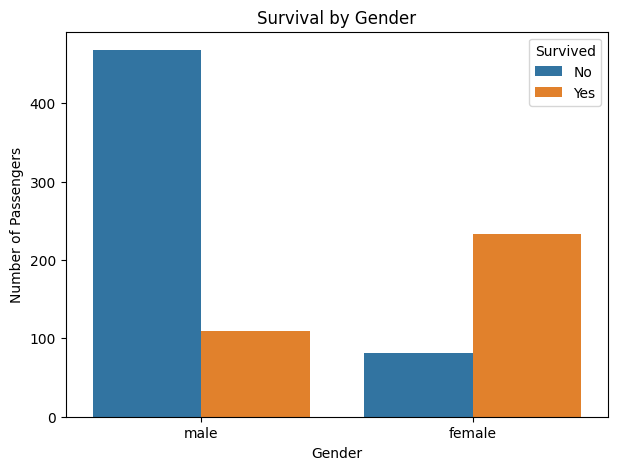

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.savefig(
    "../results/gender_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Survival Rate by Gender

In [24]:
gender_survival = (
    df_clean
    .groupby("Sex")["Survived"]
    .mean()
    * 100
)

print(gender_survival.round(2))

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


### Observation

- Female passengers had a significantly higher survival rate than male passengers.
- More than 70% of female passengers survived.
- Less than 20% of male passengers survived.
- Gender was one of the strongest factors influencing survival.

## 3. Passenger Class Analysis

This analysis examines how passenger class (First, Second, and Third Class) influenced survival during the Titanic disaster.

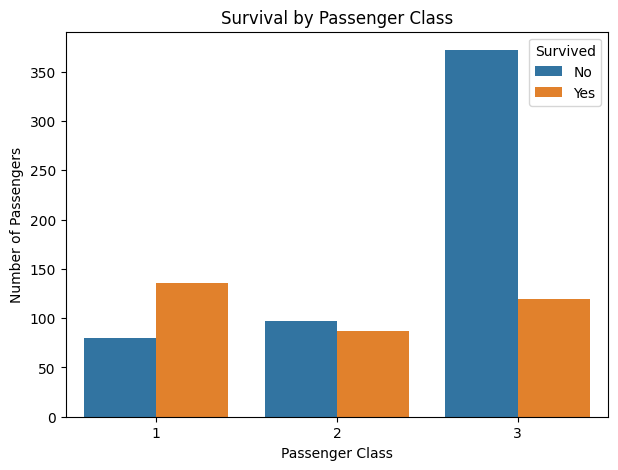

In [26]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.savefig(
    results_dir / "class_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Survival Rate by Class

In [27]:
class_survival = (
    df_clean
    .groupby("Pclass")["Survived"]
    .mean()
    * 100
)

print(class_survival.round(2))

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


### Observation

- First-class passengers had the highest survival rate.
- Second-class passengers had a moderate survival rate.
- Third-class passengers had the lowest survival rate.
- Passenger class was a significant factor affecting survival, indicating differences in access to lifeboats and evacuation opportunities.

## 4. Age Distribution Analysis

This analysis explores the age distribution of passengers and helps identify the most common passenger age groups.

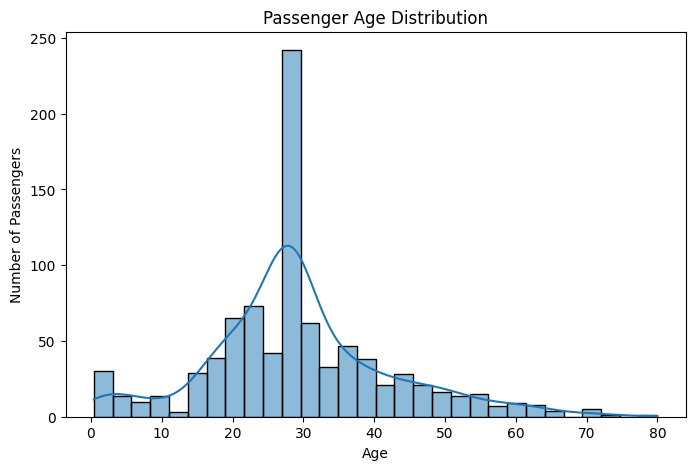

In [28]:
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)


plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Passenger Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")


plt.savefig(
    results_dir / "age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Age Distribution by Survival

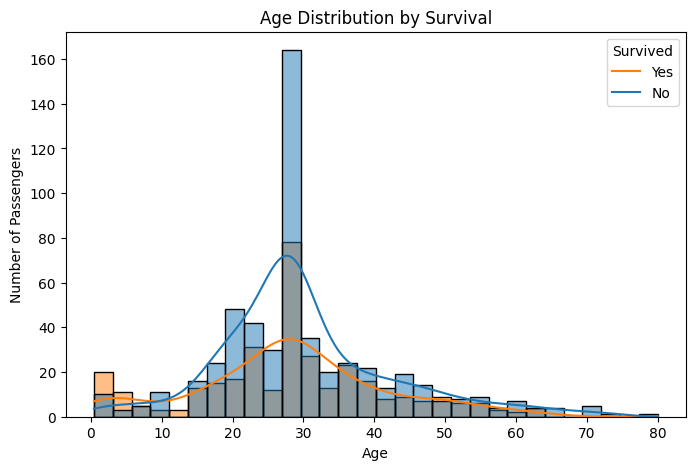

In [29]:
plt.figure(figsize=(8,5))


sns.histplot(
    data=df_clean,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)


plt.title("Age Distribution by Survival")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")


plt.legend(
    title="Survived",
    labels=["Yes", "No"]
)


plt.savefig(
    results_dir / "age_survival_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

Age Statistics

In [30]:
age_summary = df_clean["Age"].describe()

age_summary

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

### Observation

- The majority of passengers were between young adulthood and middle age.
- Children and elderly passengers represented smaller groups.
- Age distribution shows that passengers belonged to diverse age categories.
- Survival patterns varied across different age groups.

## Fare Distribution Analysis

This analysis explores the distribution of ticket fares paid by passengers.

Understanding fare distribution helps identify pricing patterns and whether ticket cost had any relationship with passenger survival.

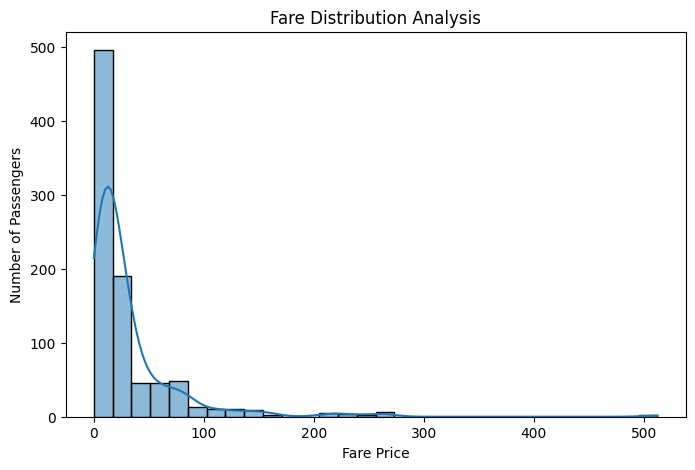

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x="Fare",
    bins=30,
    kde=True
)

plt.title(
    "Fare Distribution Analysis"
)

plt.xlabel(
    "Fare Price"
)

plt.ylabel(
    "Number of Passengers"
)

plt.savefig(
    "../results/fare_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most passengers paid lower ticket fares.
- The fare distribution is right-skewed because a small number of passengers paid very high fares.
- Higher fare values indicate that some passengers belonged to premium ticket classes.
- Fare price may have influenced survival chances because higher-class passengers generally paid higher fares.

## Family Size Analysis

Family size can influence survival chances during emergencies.

This analysis creates a new feature:
- Family_Size = SibSp + Parch + 1

The purpose is to understand whether traveling alone or with family members affected survival outcomes.

In [36]:
df_clean["Family_Size"] = (
    df_clean["SibSp"] +
    df_clean["Parch"] +
    1
)

df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


## Family Size Distribution

The distribution of family size is visualized to understand how many passengers traveled alone or with family members.

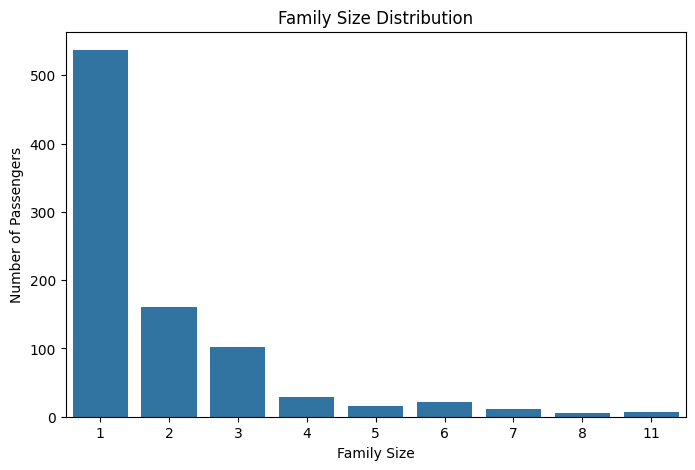

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Family_Size"
)

plt.title(
    "Family Size Distribution"
)

plt.xlabel(
    "Family Size"
)

plt.ylabel(
    "Number of Passengers"
)


plt.savefig(
    "../results/family_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most passengers traveled alone or with a small family.
- Very large families were less common on the Titanic.
- Family size may have affected survival probability because extremely large groups faced more difficulties during evacuation.

## Family Size vs Survival Analysis

This analysis explores the relationship between family size and passenger survival.

The objective is to understand whether passengers traveling alone or with family members had different survival outcomes.

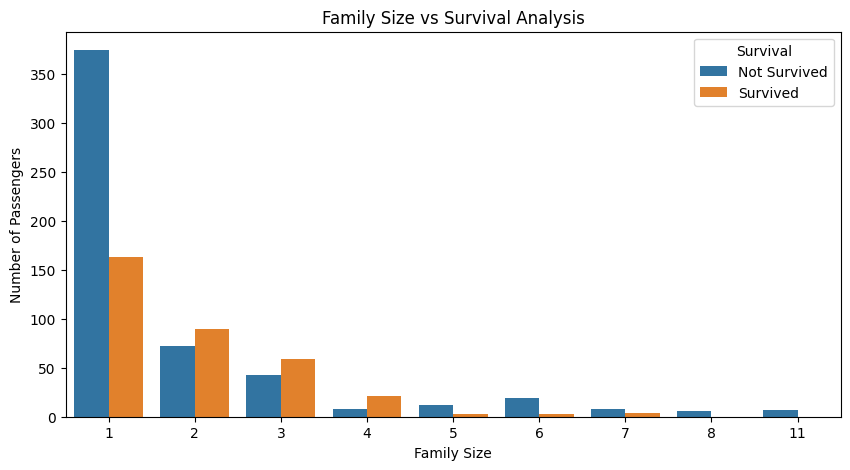

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="Family_Size",
    hue="Survived"
)

plt.title(
    "Family Size vs Survival Analysis"
)

plt.xlabel(
    "Family Size"
)

plt.ylabel(
    "Number of Passengers"
)

plt.legend(
    title="Survival",
    labels=[
        "Not Survived",
        "Survived"
    ]
)


plt.savefig(
    "../results/family_size_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Passengers traveling alone had a lower survival count compared to some small family groups.
- Very large families had fewer survivors, possibly due to difficulties during evacuation.
- Moderate family sizes showed comparatively better survival chances.
- Family size appears to have some relationship with survival outcomes.

## Correlation Heatmap Analysis

Correlation analysis helps identify relationships between numerical variables in the Titanic dataset.

The heatmap shows how strongly variables are related to each other.

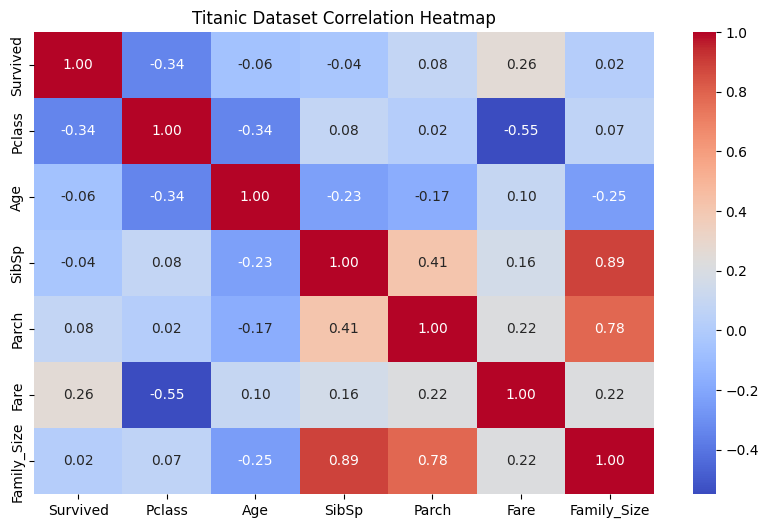

In [39]:
plt.figure(figsize=(10,6))


correlation = df_clean[
    [
        "Survived",
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Family_Size"
    ]
].corr()


sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)


plt.title(
    "Titanic Dataset Correlation Heatmap"
)


plt.savefig(
    "../results/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Observation

- Fare shows a positive relationship with survival, indicating passengers who paid higher fares had better survival chances.
- Passenger class has a negative relationship with survival because lower class passengers had lower survival rates.
- Age has a weak relationship with survival.
- Family size shows a limited correlation with survival, meaning survival depended on multiple factors.

# Final EDA Summary

The Exploratory Data Analysis of the Titanic dataset helped identify important factors that influenced passenger survival.

The analysis focused on:
- Survival distribution
- Gender-based survival patterns
- Passenger class impact
- Age distribution
- Fare analysis
- Family size impact
- Relationship between numerical variables

## Key Findings

### Survival Rate

- The dataset contains both survived and non-survived passengers.
- Survival was not evenly distributed, with more passengers not surviving.

### Gender Analysis

- Female passengers had a significantly higher survival rate compared to male passengers.
- Gender was one of the strongest factors affecting survival.

### Passenger Class Analysis

- First-class passengers had better survival chances.
- Third-class passengers experienced the highest number of fatalities.

### Age Analysis

- Most passengers were adults between approximately 20–40 years old.
- Age alone had a weaker influence compared to gender and passenger class.

### Fare Analysis

- Higher fare values were associated with better survival chances.
- Passengers paying higher fares were generally from higher passenger classes.

### Family Size Analysis

- Passengers traveling alone and with small families showed different survival patterns.
- Extremely large families had lower survival outcomes.

## Business Insights

The Titanic dataset demonstrates how multiple factors can influence outcomes.

### Customer Segmentation

Passenger class and fare can be used to identify different customer groups.

### Risk Analysis

Demographic and travel-related features can help predict survival probability.

### Data-Driven Decision Making

Historical data analysis can reveal hidden patterns and support better decision-making.

In [44]:
df_clean.to_csv(
    "../data/processed/titanic_cleaned.csv",
    index=False
)

print("Updated processed dataset saved!")

Updated processed dataset saved!


In [45]:
df_check = pd.read_csv(
    "../data/processed/titanic_cleaned.csv"
)

df_check.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1
